In [5]:
import torch
print(torch.cuda.is_available())

False


In [6]:
import SoccerNet
from SoccerNet.Downloader import SoccerNetDownloader
mySoccerNetDownloader=SoccerNetDownloader(LocalDirectory="path/to/SoccerNetGS")

In [7]:
# downloading validatation data
mySoccerNetDownloader.downloadDataTask(task="gamestate-2024", split=["valid"])

path/to/SoccerNetGS/gamestate-2024/valid.zip already exists


In [7]:
import zipfile
# replace filepath with your specific filepath
path = "path/to/SoccerNetGS/gamestate-2024/valid.zip"
with zipfile.ZipFile(path, "r") as zip_ref:
    # this takes all json files where we have our labels
    json_files = [json for json in zip_ref.namelist() if json.endswith(".json")]

    print(f"Found {len(json_files)} labeled json files")
    print(f"Sample: {json_files[:5]}")

    # extracting labeled files
    zip_ref.extractall(path="data/raw/", members = json_files)

Found 59 labeled json files
Sample: ['SNGS-033/Labels-GameState.json', 'SNGS-052/Labels-GameState.json', 'SNGS-091/Labels-GameState.json', 'SNGS-032/Labels-GameState.json', 'SNGS-078/Labels-GameState.json']


In [8]:
# inspecting label dataset
import json

with open("data/raw/SNGS-033/Labels-GameState.json", "r") as f:
    data = json.load(f)

print("Root keys:", list(data.keys()))
for k in data.keys():
    if isinstance(data[k], list):
        print(f"  '{k}': list with {len(data[k])} items")
    elif isinstance(data[k], dict):
        print(f"  '{k}': dict with keys {list(data[k].keys())}")
    else:
        print(f"  '{k}': {type(data[k]).__name__} = {data[k]}")

Root keys: ['info', 'images', 'annotations', 'categories']
  'info': dict with keys ['version', 'game_id', 'id', 'num_tracklets', 'action_position', 'action_class', 'visibility', 'game_time_start', 'game_time_stop', 'clip_start', 'clip_stop', 'name', 'im_dir', 'frame_rate', 'seq_length', 'im_ext']
  'images': list with 750 items
  'annotations': list with 9427 items
  'categories': list with 7 items


In [9]:
# Look at the first annotation entry
sample_item = data["annotations"][0]

# Pretty-print just that single dictionary
print(json.dumps(sample_item, indent=2))

{
  "id": "2033000001",
  "image_id": "2033000001",
  "track_id": 1,
  "supercategory": "object",
  "category_id": 3,
  "attributes": {
    "role": "referee",
    "jersey": null,
    "team": null
  },
  "bbox_image": {
    "x": 1441,
    "y": 798,
    "x_center": 1472.0,
    "y_center": 868.0,
    "w": 62,
    "h": 140
  },
  "bbox_pitch": {
    "x_bottom_left": 17.94676853811122,
    "y_bottom_left": 34.2566329130484,
    "x_bottom_right": 18.61722546005316,
    "y_bottom_right": 34.691501543313194,
    "x_bottom_middle": 18.2822622968887,
    "y_bottom_middle": 34.475176364049915
  },
  "bbox_pitch_raw": {
    "x_bottom_left": 18.378800225740804,
    "y_bottom_left": 34.13199405481367,
    "x_bottom_right": 19.04465313885331,
    "y_bottom_right": 34.567908270471165,
    "x_bottom_middle": 18.71196452007346,
    "y_bottom_middle": 34.35119730208327
  }
}


In [17]:
"""
This cell saves necessary data for YOLO box positioning to build a 3d to 2d map
projection model
"""
import polars as pl
import json
from pathlib import Path

records = []
path = Path("data/raw/")
pattern = "*SNGS*/*.json"
for file_path in path.glob(pattern):
    if file_path.is_file():
        print(f"Opening file: {file_path.name}")
        with open(file_path, "r") as f:
            data = json.load(f)
            for ann in data["annotations"]:
                # what we want the dictionary to look like in polars
                if "bbox_image" not in ann or "track_id" not in ann:
                    continue
                pitch_info = ann.get("bbox_pitch")
                record = {
                    "clip_id": data.get("info", {}).get("name"),
                    "image_id": ann["image_id"],
                    "track_id": ann.get("track_id"),
                    "role": ann.get("attributes", {}).get("role"),
                    "team": ann.get("attributes", {}).get("team"),
                    "jersey": ann.get("attributes", {}).get("jersey"),
                    "bbox_x1": ann["bbox_image"]["x"],
                    "bbox_y1": ann["bbox_image"]["y"],
                    "bbox_x2": ann["bbox_image"]["x"] + ann["bbox_image"]["w"],
                    "bbox_y2": ann["bbox_image"]["y"] + ann["bbox_image"]["h"],
                    "pitch_x_m": ann["bbox_pitch"]["x_bottom_middle"]
                    if pitch_info
                    else None,
                    "pitch_y_m": ann["bbox_pitch"]["y_bottom_middle"]
                    if pitch_info
                    else None,
                }
                records.append(record)
                
df = pl.DataFrame(records)

print(df.shape)
print(df["clip_id"].n_unique())

Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameState.json
Opening file: Labels-GameSta

In [18]:
df.head()

clip_id,image_id,track_id,role,team,jersey,bbox_x1,bbox_y1,bbox_x2,bbox_y2,pitch_x_m,pitch_y_m
str,str,i64,str,str,str,i64,i64,i64,i64,f64,f64
"""SNGS-039""","""2039000001""",1,"""player""","""right""","""23""",377,723,418,844,-40.157759,33.871538
"""SNGS-039""","""2039000001""",2,"""goalkeeper""","""left""",null,1285,385,1313,467,-49.690928,3.592799
"""SNGS-039""","""2039000001""",3,"""player""","""right""","""20""",359,593,427,690,-47.02089,28.830346
"""SNGS-039""","""2039000001""",4,"""referee""",null,null,1618,624,1657,734,-30.917567,16.404741
"""SNGS-039""","""2039000001""",5,"""player""","""left""","""36""",508,597,566,688,-45.894067,27.366738


In [1]:
# writing to parquet files

from pathlib import Path
Path("data/processed").mkdir(parents=True, exist_ok=True)

df.write_parquet("data/processed/annotations.parquet")

NameError: name 'df' is not defined

In [10]:
import polars as pl

df = pl.read_parquet("data/processed/annotations.parquet")
df.head()

clip_id,image_id,track_id,role,team,jersey,bbox_x1,bbox_y1,bbox_x2,bbox_y2,pitch_x_m,pitch_y_m
str,str,i64,str,str,str,i64,i64,i64,i64,f64,f64
"""SNGS-039""","""2039000001""",1,"""player""","""right""","""23""",377,723,418,844,-40.157759,33.871538
"""SNGS-039""","""2039000001""",2,"""goalkeeper""","""left""",null,1285,385,1313,467,-49.690928,3.592799
"""SNGS-039""","""2039000001""",3,"""player""","""right""","""20""",359,593,427,690,-47.02089,28.830346
"""SNGS-039""","""2039000001""",4,"""referee""",null,null,1618,624,1657,734,-30.917567,16.404741
"""SNGS-039""","""2039000001""",5,"""player""","""left""","""36""",508,597,566,688,-45.894067,27.366738


In [11]:
print(df["role"].value_counts())

shape: (5, 2)
┌────────────┬────────┐
│ role       ┆ count  │
│ ---        ┆ ---    │
│ str        ┆ u32    │
╞════════════╪════════╡
│ referee    ┆ 61847  │
│ other      ┆ 399    │
│ goalkeeper ┆ 26020  │
│ ball       ┆ 40900  │
│ player     ┆ 619500 │
└────────────┴────────┘


In [12]:
print(df.filter(pl.col("role") == "player")["team"].value_counts())

shape: (2, 2)
┌───────┬────────┐
│ team  ┆ count  │
│ ---   ┆ ---    │
│ str   ┆ u32    │
╞═══════╪════════╡
│ left  ┆ 306888 │
│ right ┆ 312612 │
└───────┴────────┘


In [13]:
print(
    df.select(
        pl.col("bbox_x1").min().alias("min_x1"),
        pl.col("bbox_x2").max().alias("max_x2"),
        pl.col("bbox_y1").min().alias("min_y1"),
        pl.col("bbox_y2").max().alias("max_y2"),
    )
)

shape: (1, 4)
┌────────┬────────┬────────┬────────┐
│ min_x1 ┆ max_x2 ┆ min_y1 ┆ max_y2 │
│ ---    ┆ ---    ┆ ---    ┆ ---    │
│ i64    ┆ i64    ┆ i64    ┆ i64    │
╞════════╪════════╪════════╪════════╡
│ 0      ┆ 1920   ┆ 0      ┆ 1080   │
└────────┴────────┴────────┴────────┘


In [16]:
import zipfile
img_path = "path/to/SoccerNetGS/gamestate-2024/valid.zip"

with zipfile.ZipFile(img_path, "r") as zip_ref:
    zip_ref.extract('SNGS-039/img1/000001.jpg', 'data/raw/SNGS-039')

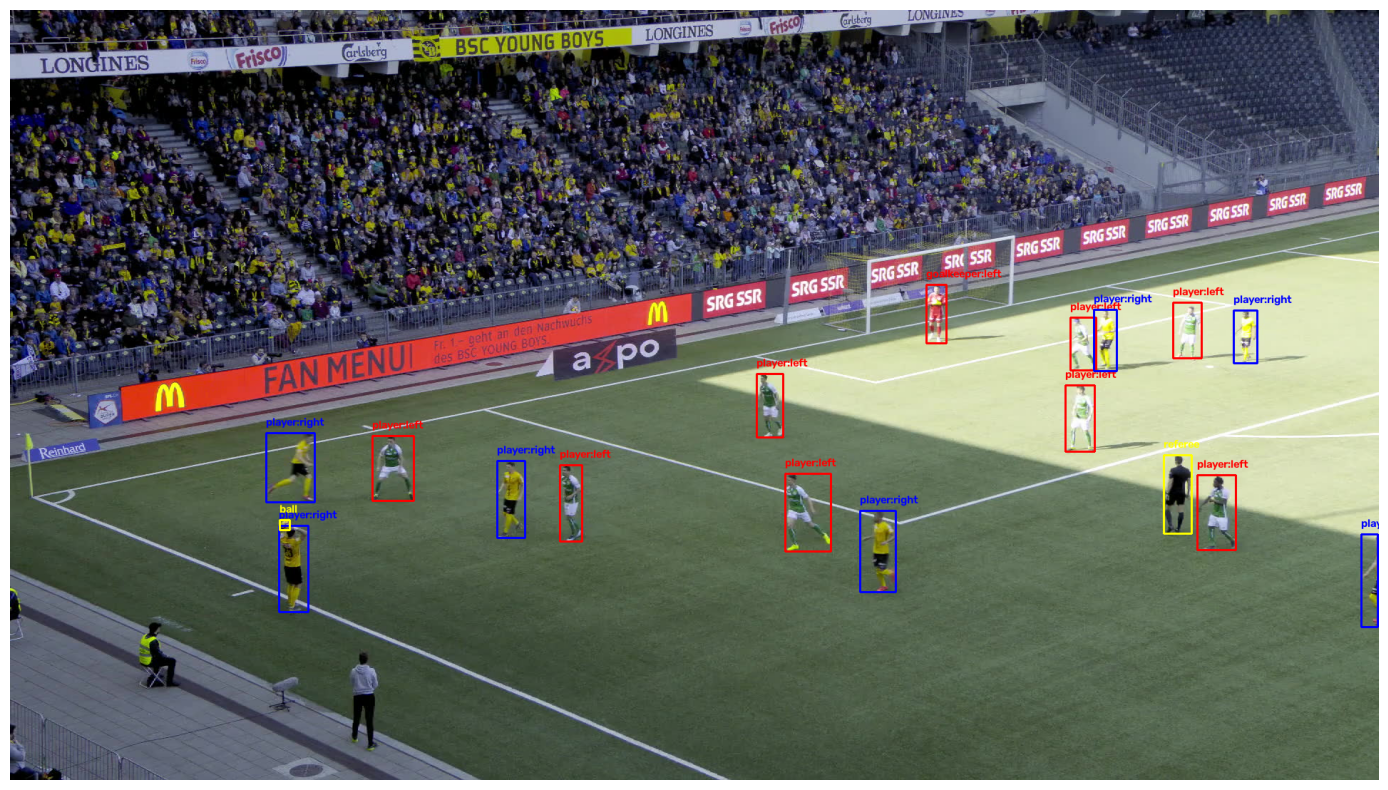

In [17]:
import cv2
import matplotlib.pyplot as plt

img_path = "data/raw/SNGS-039/000001.jpg"

image = cv2.imread(img_path)
img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# fetching frame annotations for this image
frame_anns = df.filter(
    pl.col("clip_id") == "SNGS-039",
    pl.col("image_id") == "2039000001"
)

colors = {
    "left" : (255, 0, 0),
    "right" : (0, 0, 255),
    None : (255, 255, 0) # referees or smth
}


for row in frame_anns.iter_rows(named=True):
    x1, x2 = row["bbox_x1"], row["bbox_x2"]
    y1, y2 = row["bbox_y1"], row["bbox_y2"]
    team = row["team"]
    role = row["role"]
    color = colors.get(team, (255, 255, 0))
    cv2.rectangle(img, (x1, y1), (x2,y2), color, 2)
    team_role = f"{role}:{team}" if team else role
    cv2.putText(img, team_role, (x1,max(y1-10, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(20,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [20]:
"""
This cell is to crop every player for every image in the dataset to train
resnet model to identify players
"""

import polars as pl
import zipfile
import numpy as np
from pathlib import Path
import cv2
from collections import defaultdict

output_dir = Path("data/processed/crops")
output_dir.mkdir(parents=True,exist_ok=True)
# filters for only players, excludes degenerate bbox dims
players_df = df.filter(
                pl.col("role") == "player", 
                (pl.col("bbox_x2") - pl.col("bbox_x1") >= 10),  # width
                (pl.col("bbox_y2") - pl.col("bbox_y1") >= 20)   # height
            )

# separating images to split and val
unique_clips = players_df["clip_id"].unique().to_list()

np.random.seed(42)
np.random.shuffle(unique_clips)

split_idx = int(len(unique_clips) * 0.8)
train_clips = unique_clips[:split_idx]
val_clips = unique_clips[split_idx:]

train_df = players_df.filter(pl.col("clip_id").is_in(train_clips))
val_df = players_df.filter(pl.col("clip_id").is_in(val_clips))

# cropped image metadata
crop_manifest = []

# lookup so we don't need to recompute dataframe filtering
ann_lookup = defaultdict(list)

for row in players_df.iter_rows(named = True):
    key = (row["clip_id"], row["image_id"])
    ann_lookup[key].append(row)


path = "path/to/SoccerNetGS/gamestate-2024/valid.zip"
img_extensions = (".png", ".jpeg", ".jpg")

processed_frames = 0
with zipfile.ZipFile(path, "r") as zip_ref:
    for img_path in zip_ref.namelist():
        if img_path.endswith(img_extensions):
            p = Path(img_path)
            
            clip_id = p.parts[0]
            frame_num = p.stem

            # extracts every 5th frame to get more diversity, minimize computation time.
            if int(frame_num) % 5 != 0:
                continue
            
            clip_num = clip_id.split("-")[1] # ex: 'SNGS-039' -> 039
            image_id = f"2{clip_num}{frame_num}"

            frame_anns = ann_lookup.get((clip_id, image_id), [])
            # if frame metadata not present, skip
            if not frame_anns:
                continue
            
            img_bytes = np.frombuffer(zip_ref.read(img_path), np.uint8)
            image = cv2.imdecode(img_bytes, cv2.IMREAD_COLOR)
            

            for idx, row in enumerate(frame_anns):
                
                x1, x2 = row["bbox_x1"], row["bbox_x2"]
                y1, y2 = row["bbox_y1"], row["bbox_y2"]

                # ensuring coordinates are within frame boundaries
                h, w, _ = image.shape
                y1, y2 = max(0, y1), min(h, y2)
                x1, x2 = max(0, x1), min(w, x2)
                
                cropped_img = image[y1:y2, x1:x2]

                # ensures no false crops
                if cropped_img.size == 0:
                    continue

                clip_dir = output_dir / clip_id
                clip_dir.mkdir(parents=True, exist_ok=True)
                crop_file_path = clip_dir / f"crop_{image_id}_{idx}.jpg"
                cv2.imwrite(str(crop_file_path), cropped_img)

                crop_manifest.append(
                    {
                        "crop_path" : str(crop_file_path),
                        "clip_id" : clip_id,
                        "image_id" : image_id,
                        "track_id" : row["track_id"],
                        "team" : row["team"],
                        "split" : "train" if clip_id in train_clips else "val"
                    }
                )
            
            processed_frames += 1
            if processed_frames % 500 == 0:
                print(f"processed {processed_frames} frames | saved {len(crop_manifest)} crops so far...")
                
            
manifest_df = pl.DataFrame(crop_manifest)
manifest_df.write_parquet("data/processed/crop_manifest.parquet")
print(f"saved {len(manifest_df)} crop records to manifest")
                
        

processed 500 frames | saved 6479 crops so far...
processed 1000 frames | saved 13078 crops so far...
processed 1500 frames | saved 19903 crops so far...
processed 2000 frames | saved 26645 crops so far...
processed 2500 frames | saved 35213 crops so far...
processed 3000 frames | saved 42168 crops so far...
processed 3500 frames | saved 50101 crops so far...
processed 4000 frames | saved 57089 crops so far...
processed 4500 frames | saved 63089 crops so far...
processed 5000 frames | saved 71092 crops so far...
processed 5500 frames | saved 77411 crops so far...
processed 6000 frames | saved 84330 crops so far...
processed 6500 frames | saved 91709 crops so far...
processed 7000 frames | saved 99471 crops so far...
processed 7500 frames | saved 106604 crops so far...
processed 8000 frames | saved 113191 crops so far...
processed 8500 frames | saved 120179 crops so far...
saved 123576 crop records to manifest


In [19]:
df.filter(
    (pl.col("clip_id") == "SNGS-033") & (pl.col("image_id") == "2033000389")
)["role"].value_counts()

role,count
str,u32
"""goalkeeper""",1
"""referee""",1
"""ball""",1
"""player""",3
